# Cluster TMatrices

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0 = 2 * np.pi / 1000
materials = [treams.Material(16 + 0.5j), treams.Material()]
lmax = 3
radii = [110, 90, 80, 75]
positions = (220 / np.sqrt(24)) * np.array(
    [
        [np.sqrt(8), 0, -1],
        [-np.sqrt(2), np.sqrt(6), -1],
        [-np.sqrt(2), -np.sqrt(6), -1],
        [0, 0, 3],
    ]
)

In [4]:
spheres = [treams.TMatrix.sphere(lmax, k0, r, materials) for r in radii]
tm = treams.TMatrix.cluster(spheres, positions).interaction.solve()

/home/runner/work/treams/treams/src/treams/_operators.py:579: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.translate(


In [5]:
inc = treams.plane_wave([k0, 0, 0], 0, k0=tm.k0, material=tm.material)
sca = tm @ inc.expand(tm.basis)
xs = tm.xs(inc)

/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:579: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.translate(


In [6]:
x = np.linspace(-300, 300, 101)
y = 0
z = np.linspace(-300, 300, 101)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [7]:
intensity = np.zeros_like(xx)
valid = tm.valid_points(grid, radii)
intensity[~valid] = np.nan
intensity[valid] = 0.5 * np.sum(
    np.abs(inc.efield(grid[valid]) + sca.efield(grid[valid])) ** 2, -1
)

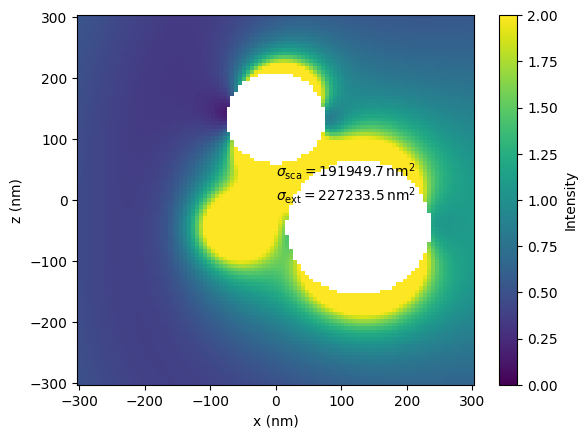

In [8]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, zz, intensity, shading="nearest", vmin=0, vmax=2,
)
cb = plt.colorbar(pcm)
cb.set_label("Intensity")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.text(
    0,
    0,
    r"$\sigma_\mathrm{sca} = "
    f"{xs[0]:.7}\\,$nm$^2$\n"
    r"$\sigma_\mathrm{ext} = "
    f"{xs[1]:.7}\\,$nm$^2$",
)
fig.show()

In [9]:
tm_global = tm.expand(treams.SphericalWaveBasis.default(6))
sca = tm_global @ inc.expand(tm_global.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:579: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.translate(
/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(


In [10]:
xs = tm_global.xs(inc)

/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:579: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.translate(


In [11]:
x = np.linspace(-300, 300, 101)
y = 0
z = np.linspace(-300, 300, 101)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [12]:
intensity_global = np.zeros_like(xx)
valid = tm_global.valid_points(grid, [260])
intensity_global[~valid] = np.nan
intensity_global[valid] = 0.5 * np.sum(
    np.abs(inc.efield(grid[valid]) + sca.efield(grid[valid])) ** 2, -1
)

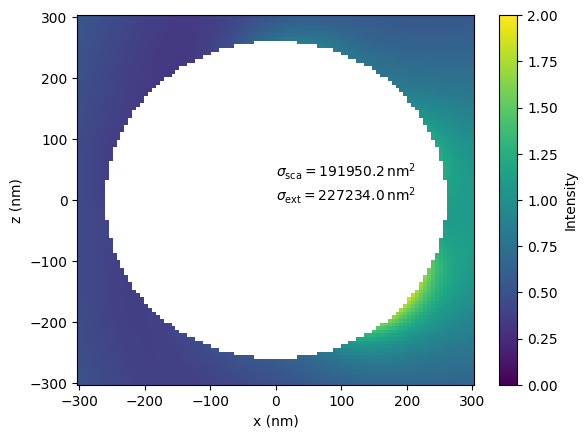

In [13]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, zz, intensity_global, shading="nearest", vmin=0, vmax=2,
)
cb = plt.colorbar(pcm)
cb.set_label("Intensity")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.text(
    0,
    0,
    r"$\sigma_\mathrm{sca} = "
    f"{xs[0]:.7}\\,$nm$^2$\n"
    r"$\sigma_\mathrm{ext} = "
    f"{xs[1]:.7}\\,$nm$^2$",
)
fig.show()

In [14]:
inc = treams.plane_wave([0, 0, -k0], 0, k0=tm.k0, material=tm.material)
tm_rotate = tm_global.rotate(0, np.pi / 2)
sca = tm_rotate @ inc.expand(tm_rotate.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:201: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.rotate(
/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(


In [15]:
xs = tm_rotate.xs(inc)

/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:579: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.translate(


In [16]:
x = np.linspace(-300, 300, 101)
y = 0
z = np.linspace(-300, 300, 101)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [17]:
intensity_global = np.zeros_like(xx)
valid = tm_rotate.valid_points(grid, [260])
intensity_global[~valid] = np.nan
intensity_global[valid] = 0.5 * np.sum(
    np.abs(inc.efield(grid[valid]) + sca.efield(grid[valid])) ** 2, -1
)

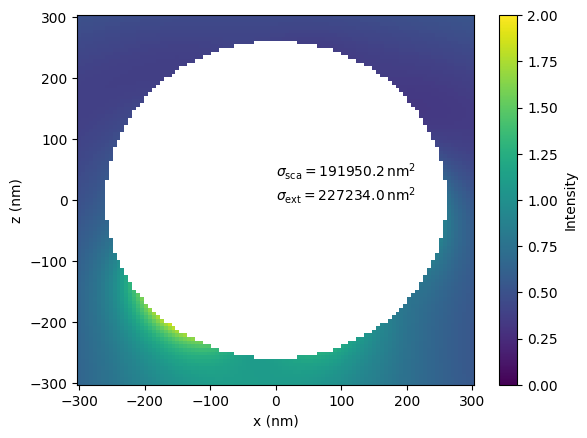

In [18]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, zz, intensity_global, shading="nearest", vmin=0, vmax=2,
)
cb = plt.colorbar(pcm)
cb.set_label("Intensity")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.text(
    0,
    0,
    r"$\sigma_\mathrm{sca} = "
    f"{xs[0]:.7}\\,$nm$^2$\n"
    r"$\sigma_\mathrm{ext} = "
    f"{xs[1]:.7}\\,$nm$^2$",
)
fig.show()